THIS SCRIPT SHOWS EXAMPLE FOR PLOTTING NDA SPECTRA STOKES I AND V

In [1]:
from astropy.io import fits
import numpy as np
from astropy.time import Time
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm

READ FITS FILE

In [2]:
print('Reading the file...')

fitsfile = '/Users/shilpibhunia/Documents/projects/March_2025_campaign/event_2025_03_26/orn_nda_newroutine_sun_edr_202503260756_202503261555_v1.1.fits'
hdul = fits.open(fitsfile)


Reading the file...


GET FREQUENCY AND TIME

In [3]:
freq = hdul[1].data[0][0]
times = []
for i in range(hdul[2].data.shape[0]):
    t = Time(hdul[2].data[i][0], format='jd')
    t = datetime.strptime(t.to_value('isot'), '%Y-%m-%dT%H:%M:%S.%f')
    times.append(t)

times = np.array(times)

SELECT TIME RANGE FOR PLOTTING THE DATA

In [4]:
startt = datetime(2025, 3, 26, 9, 21)
endt   = datetime(2025, 3, 26, 9, 51)

startid = np.argmin(np.abs(times - startt))
endid   = np.argmin(np.abs(times - endt))

Times = times[startid:endid]
Data  = hdul[2].data[startid:endid]

print("Selected time range:", Times[0], "to", Times[-1])


Selected time range: 2025-03-26 09:21:00.243000 to 2025-03-26 09:50:59.731000


EXTRACT LL & RR

In [5]:
ldata = np.array([row[1][:, 0] for row in Data])
rdata = np.array([row[1][:, 1] for row in Data])

print("ldata shape:", ldata.shape)
print("rdata shape:", rdata.shape)

ldata shape: (3661, 1598)
rdata shape: (3661, 1598)


COMPUTE STOKES I & V

In [7]:
I = (ldata + rdata) / 2.0
V = (rdata - ldata) / 2.0

DATA PERCENTILE FOR PLOTTING

In [8]:
# For I (log scale)
I[I <= 0] = np.nan
vmin_I = np.nanpercentile(I, 5)
vmax_I = np.nanpercentile(I, 95)

# For V (symmetric scale)
vmax_V = np.nanpercentile(np.abs(V), 70)

PLOT STOKES I AND V

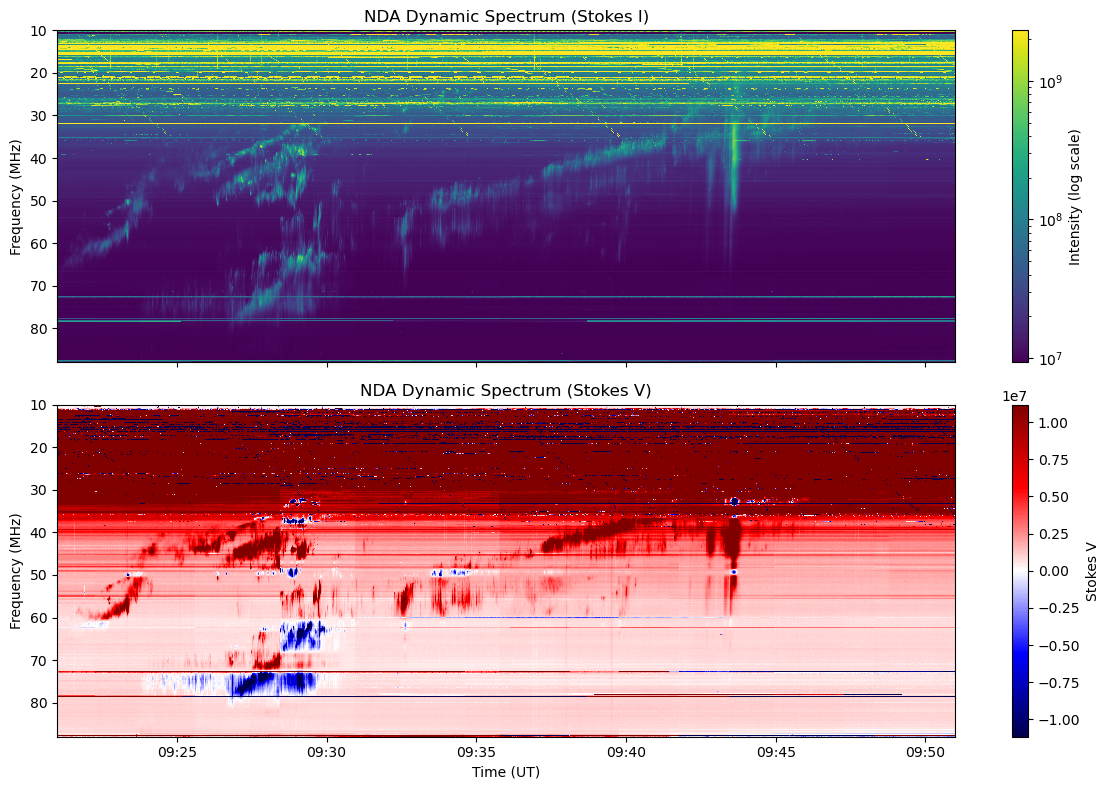

In [10]:
time_nums = mdates.date2num(Times)

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ---- Stokes I ----
im1 = axs[0].pcolormesh(time_nums, freq, I.T,
                        shading='auto',
                        cmap='viridis',
                        norm=LogNorm(vmin=vmin_I, vmax=vmax_I))

axs[0].set_ylabel('Frequency (MHz)')
axs[0].set_title('NDA Dynamic Spectrum (Stokes I)')
axs[0].invert_yaxis()

cbar1 = plt.colorbar(im1, ax=axs[0])
cbar1.set_label('Intensity (log scale)')

# ---- Stokes V ----
im2 = axs[1].pcolormesh(time_nums, freq, V.T,
                        shading='auto',
                        cmap='seismic',
                        vmin=-vmax_V,
                        vmax=+vmax_V)

axs[1].set_ylabel('Frequency (MHz)')
axs[1].set_title('NDA Dynamic Spectrum (Stokes V)')
axs[1].invert_yaxis()

cbar2 = plt.colorbar(im2, ax=axs[1])
cbar2.set_label('Stokes V')

# ---- Time axis formatting ----
axs[1].xaxis_date()
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlabel('Time (UT)')

plt.tight_layout()
